### **Import Required Libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler



### **Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/jm1.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (10885, 22)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,23029.10,...,51,10,8,1,17,36,112,86,13,True
3,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,74202.67,...,129,29,28,2,17,135,329,271,5,True
4,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,10297.30,...,28,1,6,0,11,16,76,50,7,True


### **Handle Missing Values (?)**

In [ ]:
# Replace '?' with NaN
df.replace("?", np.nan, inplace=True)

# Convert feature columns to numeric
for col in df.columns:
    if col != "defects":
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert target column
df["defects"] = df["defects"].astype(int)

print("Missing values after replacement:")
print(df.isnull().sum())


Missing values after replacement:
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              5
uniq_Opnd            5
total_Op             5
total_Opnd           5
branchCount          5
defects              0
dtype: int64


### **Impute Missing Values (Median)**

In [ ]:
df.fillna(df.median(), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64


### **Outlier Analysis (IQR Method – Detection Only)**

In [ ]:
def detect_outliers_iqr(data):
    outlier_count = {}
    for col in data.columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count[col] = ((data[col] < lower) | (data[col] > upper)).sum()
    return outlier_count

X_numeric = df.drop("defects", axis=1)
outliers = detect_outliers_iqr(X_numeric)

# Show top 10 features with most outliers
print(sorted(outliers.items(), key=lambda x: x[1], reverse=True)[:10])


[('e', np.int64(1579)), ('t', np.int64(1579)), ('lOComment', np.int64(1458)), ('ev(g)', np.int64(1371)), ('locCodeAndComment', np.int64(1309)), ('l', np.int64(1131)), ('v', np.int64(1106)), ('b', np.int64(1102)), ('total_Opnd', np.int64(1043)), ('n', np.int64(1006))]


### **Outlier Handling (Capping / Winsorization)**

In [ ]:
for col in X_numeric.columns:
    lower = X_numeric[col].quantile(0.01)
    upper = X_numeric[col].quantile(0.99)
    X_numeric[col] = X_numeric[col].clip(lower, upper)

df[X_numeric.columns] = X_numeric


### **Feature–Target Split**

In [ ]:
X = df.drop("defects", axis=1)
y = df["defects"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (10885, 21)
Target shape: (10885,)


### **Train–Test Split (Stratified)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (8708, 21)
Test set: (2177, 21)


### **Feature Scaling (RobustScaler – Recommended)**

In [ ]:
scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed successfully!")


Scaling completed successfully!


### **Final Verification**

In [ ]:
print("Final Training Set:", X_train.shape, y_train.shape)
print("Final Test Set:", X_test.shape, y_test.shape)
print("Preprocessing pipeline completed successfully ✔️")


Final Training Set: (8708, 21) (8708,)
Final Test Set: (2177, 21) (2177,)
Preprocessing pipeline completed successfully ✔️


### **Train RANDOM FOREST Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))


Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1756
           1       0.49      0.24      0.33       421

    accuracy                           0.80      2177
   macro avg       0.66      0.59      0.61      2177
weighted avg       0.77      0.80      0.78      2177

Confusion Matrix:

[[1649  107]
 [ 318  103]]
ROC-AUC Score: 0.7146721927940309


### **Train XGBOOST Classifier**

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_xgb))


XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.78      0.83      1756
           1       0.37      0.53      0.44       421

    accuracy                           0.73      2177
   macro avg       0.62      0.66      0.63      2177
weighted avg       0.78      0.73      0.75      2177

Confusion Matrix:

[[1373  383]
 [ 196  225]]
ROC-AUC Score: 0.7238264193616457


### **Model Performance Comparison**

In [ ]:
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


Random Forest ROC-AUC: 0.7146721927940309
XGBoost ROC-AUC: 0.7238264193616457


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd


In [ ]:
def evaluate_model(model, X_test, y_test, y_prob):
    acc = accuracy_score(y_test, model.predict(X_test))
    f1 = f1_score(y_test, model.predict(X_test))
    auc = roc_auc_score(y_test, y_prob)
    return acc, f1, auc


### **Logistic Regression (Baseline)**

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

lr.fit(X_train, y_train)

lr_prob = lr.predict_proba(X_test)[:, 1]
lr_acc, lr_f1, lr_auc = evaluate_model(lr, X_test, y_test, lr_prob)


### **Support Vector Machine (SVM)**

In [ ]:
svm = SVC(
    kernel="rbf",
    probability=True,
    class_weight="balanced"
)

svm.fit(X_train, y_train)

svm_prob = svm.predict_proba(X_test)[:, 1]
svm_acc, svm_f1, svm_auc = evaluate_model(svm, X_test, y_test, svm_prob)


### **K-Nearest Neighbors (KNN)**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)

knn.fit(X_train, y_train)

knn_prob = knn.predict_proba(X_test)[:, 1]
knn_acc, knn_f1, knn_auc = evaluate_model(knn, X_test, y_test, knn_prob)


### **Naive Bayes (Gaussian NB)**

In [ ]:
nb = GaussianNB()

nb.fit(X_train, y_train)

nb_prob = nb.predict_proba(X_test)[:, 1]
nb_acc, nb_f1, nb_auc = evaluate_model(nb, X_test, y_test, nb_prob)


### **Decision Tree**

In [ ]:
dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

dt_prob = dt.predict_proba(X_test)[:, 1]
dt_acc, dt_f1, dt_auc = evaluate_model(dt, X_test, y_test, dt_prob)



In [ ]:
rf_acc, rf_f1, rf_auc = evaluate_model(rf_model, X_test, y_test, y_prob_rf)
xgb_acc, xgb_f1, xgb_auc = evaluate_model(xgb_model, X_test, y_test, y_prob_xgb)


### **Create Single Comparison Table**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc, svm_acc, knn_acc, nb_acc, dt_acc, rf_acc, xgb_acc
    ],
    "F1-Score": [
        lr_f1, svm_f1, knn_f1, nb_f1, dt_f1, rf_f1, xgb_f1
    ],
    "ROC-AUC": [
        lr_auc, svm_auc, knn_auc, nb_auc, dt_auc, rf_auc, xgb_auc
    ]
})

print(results.sort_values(by="ROC-AUC", ascending=False))


                 Model  Accuracy  F1-Score   ROC-AUC
6              XGBoost  0.734038  0.437318  0.723826
5        Random Forest  0.804777  0.326466  0.714672
1                  SVM  0.711070  0.423465  0.699166
0  Logistic Regression  0.704180  0.426025  0.698677
2                  KNN  0.801102  0.322379  0.682472
3          Naive Bayes  0.790078  0.371389  0.680093
4        Decision Tree  0.728985  0.337079  0.576302


In [ ]:
print(results)


                 Model  Accuracy  F1-Score   ROC-AUC
0  Logistic Regression  0.704180  0.426025  0.698677
1                  SVM  0.711070  0.423465  0.699166
2                  KNN  0.801102  0.322379  0.682472
3          Naive Bayes  0.790078  0.371389  0.680093
4        Decision Tree  0.728985  0.337079  0.576302
5        Random Forest  0.804777  0.326466  0.714672
6              XGBoost  0.734038  0.437318  0.723826


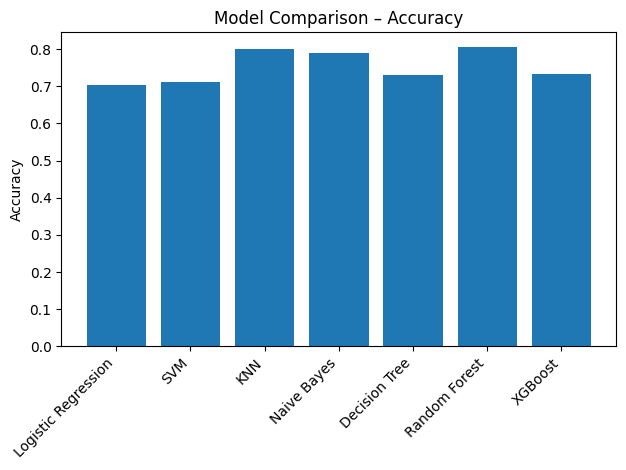

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["Accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy")
plt.title("Model Comparison – Accuracy")
plt.tight_layout()
plt.show()


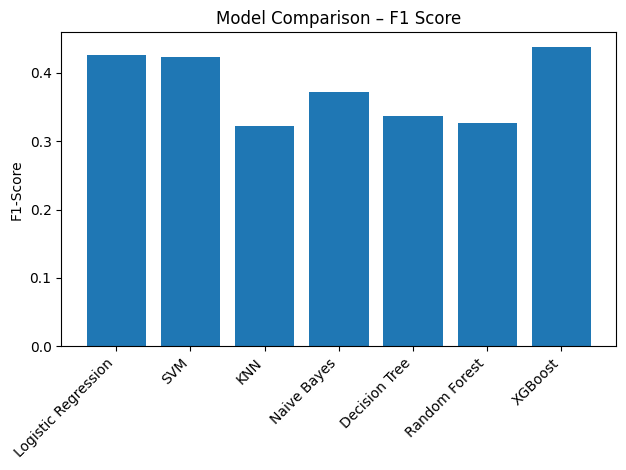

In [ ]:
plt.figure()
plt.bar(results["Model"], results["F1-Score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-Score")
plt.title("Model Comparison – F1 Score")
plt.tight_layout()
plt.show()


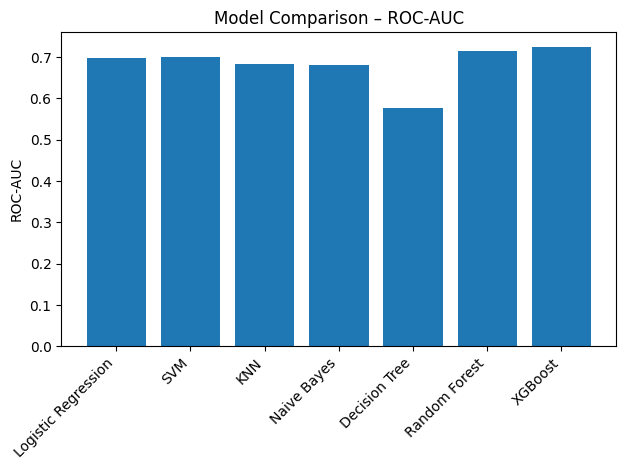

In [ ]:
plt.figure()
plt.bar(results["Model"], results["ROC-AUC"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Model Comparison – ROC-AUC")
plt.tight_layout()
plt.show()


### **Plot ROC Curve – Random Forest**

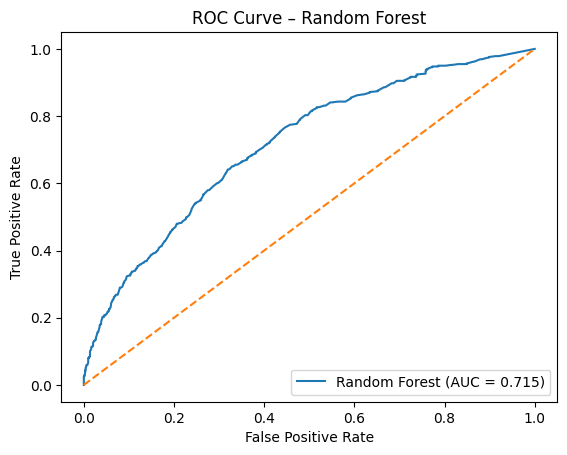

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Random Forest")
plt.legend(loc="lower right")
plt.show()


### **Plot ROC Curve – XGBoost**

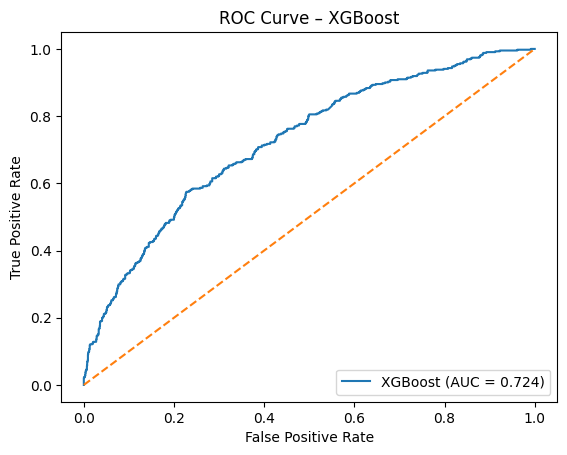

In [ ]:
# ROC curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_xgb:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend(loc="lower right")
plt.show()


### **SOFT VOTING ENSEMBLE (Random Forest + XGBoost)**

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss",
    random_state=42
)

ensemble_model = VotingClassifier(
    estimators=[
        ("RandomForest", rf),
        ("XGBoost", xgb)
    ],
    voting="soft"
)

ensemble_model.fit(X_train, y_train)
y_pred_ens = ensemble_model.predict(X_test)
y_prob_ens = ensemble_model.predict_proba(X_test)[:, 1]

print("Ensemble Model Classification Report:\n")
print(classification_report(y_test, y_pred_ens))

print("Ensemble ROC-AUC:", roc_auc_score(y_test, y_prob_ens))


Ensemble Model Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1756
           1       0.42      0.35      0.38       421

    accuracy                           0.78      2177
   macro avg       0.64      0.62      0.62      2177
weighted avg       0.77      0.78      0.77      2177

Ensemble ROC-AUC: 0.7271472359443565


### **STACKING ENSEMBLE**

In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stack_model = StackingClassifier(
    estimators=[
        ("RandomForest", rf),
        ("XGBoost", xgb)
    ],
    final_estimator=LogisticRegression(),
    passthrough=False
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
y_prob_stack = stack_model.predict_proba(X_test)[:, 1]

print("Stacking Ensemble Classification Report:\n")
print(classification_report(y_test, y_pred_stack))

print("Stacking ROC-AUC:", roc_auc_score(y_test, y_prob_stack))


Stacking Ensemble Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1756
           1       0.57      0.20      0.30       421

    accuracy                           0.82      2177
   macro avg       0.70      0.58      0.59      2177
weighted avg       0.78      0.82      0.78      2177

Stacking ROC-AUC: 0.7271391198956816


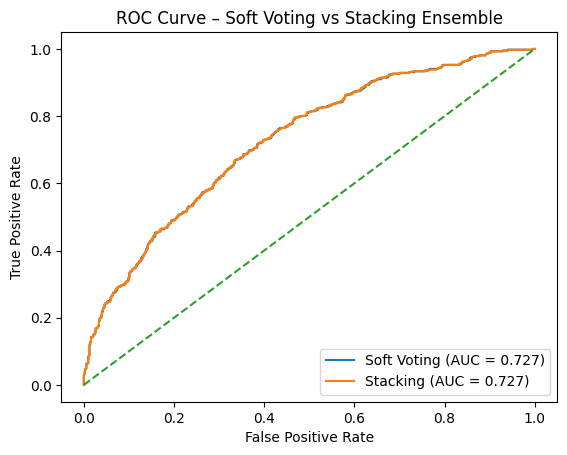

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC for Soft Voting Ensemble
fpr_soft, tpr_soft, _ = roc_curve(y_test, y_prob_ens)
auc_soft = auc(fpr_soft, tpr_soft)

# ROC for Stacking Ensemble
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_prob_stack)
auc_stack = auc(fpr_stack, tpr_stack)

plt.figure()
plt.plot(fpr_soft, tpr_soft, label=f"Soft Voting (AUC = {auc_soft:.3f})")
plt.plot(fpr_stack, tpr_stack, label=f"Stacking (AUC = {auc_stack:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Soft Voting vs Stacking Ensemble")
plt.legend(loc="lower right")
plt.show()


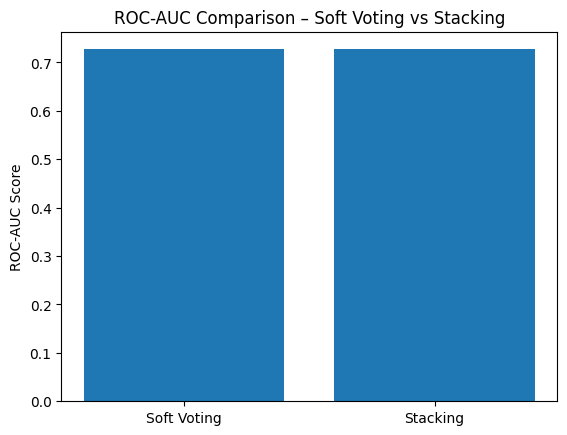

In [ ]:
models = ["Soft Voting", "Stacking"]
roc_scores = [auc_soft, auc_stack]

plt.figure()
plt.bar(models, roc_scores)
plt.ylabel("ROC-AUC Score")
plt.title("ROC-AUC Comparison – Soft Voting vs Stacking")
plt.show()


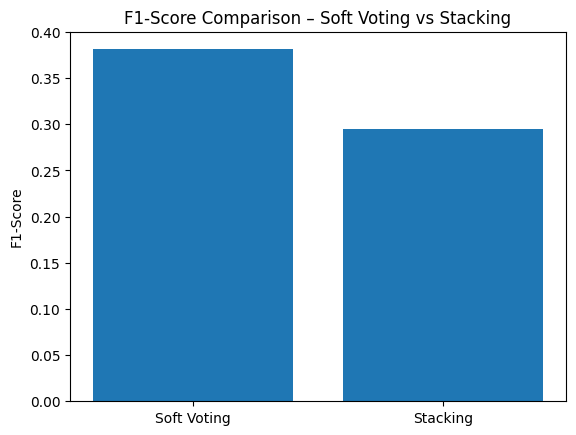

In [ ]:
from sklearn.metrics import f1_score

f1_soft = f1_score(y_test, y_pred_ens)
f1_stack = f1_score(y_test, y_pred_stack)

plt.figure()
plt.bar(models, [f1_soft, f1_stack])
plt.ylabel("F1-Score")
plt.title("F1-Score Comparison – Soft Voting vs Stacking")
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

# Accuracy for Soft Voting Ensemble
acc_soft = accuracy_score(y_test, y_pred_ens)

# Accuracy for Stacking Ensemble
acc_stack = accuracy_score(y_test, y_pred_stack)

print("Soft Voting Accuracy:", acc_soft)
print("Stacking Accuracy:", acc_stack)


Soft Voting Accuracy: 0.7822691777675701
Stacking Accuracy: 0.8158015617822691


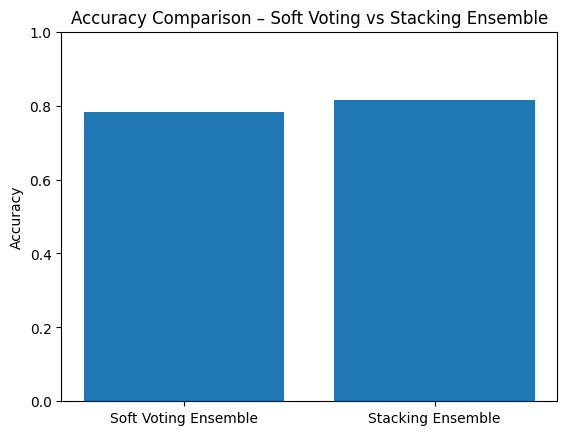

In [ ]:
import matplotlib.pyplot as plt

models = ["Soft Voting Ensemble", "Stacking Ensemble"]
accuracies = [acc_soft, acc_stack]

plt.figure()
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison – Soft Voting vs Stacking Ensemble")
plt.ylim(0, 1)
plt.show()


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "KNN",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Soft Voting Ensemble",
        "Stacking Ensemble"
    ],
    "Accuracy": [
        lr_acc, svm_acc, knn_acc, nb_acc, dt_acc,
        rf_acc, xgb_acc, acc_soft, acc_stack
    ],
    "F1-Score": [
        lr_f1, svm_f1, knn_f1, nb_f1, dt_f1,
        rf_f1, xgb_f1, f1_soft, f1_stack
    ],
    "ROC-AUC": [
        lr_auc, svm_auc, knn_auc, nb_auc, dt_auc,
        rf_auc, xgb_auc, auc_soft, auc_stack
    ]
})

print(results)


                  Model  Accuracy  F1-Score   ROC-AUC
0   Logistic Regression  0.704180  0.426025  0.698677
1                   SVM  0.711070  0.423465  0.699166
2                   KNN  0.801102  0.322379  0.682472
3           Naive Bayes  0.790078  0.371389  0.680093
4         Decision Tree  0.728985  0.337079  0.576302
5         Random Forest  0.804777  0.326466  0.714672
6               XGBoost  0.734038  0.437318  0.723826
7  Soft Voting Ensemble  0.782269  0.381201  0.727147
8     Stacking Ensemble  0.815802  0.295255  0.727139


In [ ]:
# Sort by ROC-AUC first, then by F1-score
best_model = results.sort_values(
    by=["ROC-AUC", "F1-Score"],
    ascending=False
).iloc[0]

print("🏆 BEST MODEL SELECTED 🏆")
print(best_model)


🏆 BEST MODEL SELECTED 🏆
Model       Soft Voting Ensemble
Accuracy                0.782269
F1-Score                0.381201
ROC-AUC                 0.727147
Name: 7, dtype: object


In [ ]:
best_model_name = best_model["Model"]

if best_model_name == "Stacking Ensemble":
    final_model = stack_model
elif best_model_name == "Soft Voting Ensemble":
    final_model = ensemble_model
elif best_model_name == "XGBoost":
    final_model = xgb_model
elif best_model_name == "Random Forest":
    final_model = rf_model
